# Sentiment Analysis on Financial Text. Uses ELMo for word embeddings and testing 3 different models.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import tensorflow as tf
import tensorflow_hub as hub

In [3]:
import chardet

with open('/content/all-data.csv', 'rb') as f:
    result = chardet.detect(f.read())

print(result)

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [4]:
df = pd.read_csv('/content/all-data.csv', encoding=result['encoding'], header=None)
df.head()

,0,1
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [5]:
df.columns = ['label', 'text']
df.head()

,label,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


<Axes: xlabel='label'>

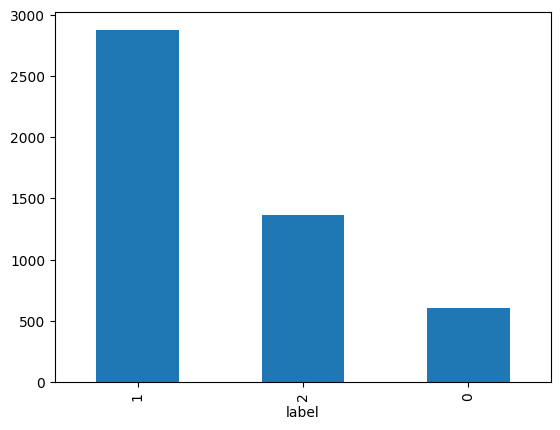

In [6]:
label_map = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}
df['label'] = df['label'].map(label_map)
df['label'].value_counts().plot(kind='bar')

In [7]:
df.head()

,label,text
0,1,"According to Gran , the company has no plans t..."
1,1,Technopolis plans to develop in stages an area...
2,0,The international electronic industry company ...
3,2,With the new production plant the company woul...
4,2,According to the company 's updated strategy f...


In [8]:
duplicate_text = df.duplicated(subset=['text'])
print(f'Number of duplicates: {duplicate_text.sum()}')
print('Indices and text of duplicate rows:')
print(df.loc[duplicate_text, 'text'])

Number of duplicates: 8
Indices and text of duplicate rows:
79      TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...
789     The Group 's business is balanced by its broad...
1099    The issuer is solely responsible for the conte...
1416    The report profiles 614 companies including ma...
2396    Ahlstrom 's share is quoted on the NASDAQ OMX ...
2567    SSH Communications Security Corporation is hea...
3094    Proha Plc ( Euronext :7327 ) announced today (...
3206    The company serves customers in various indust...
Name: text, dtype: object


In [9]:
label_distribution = df['label'].value_counts()
print(label_distribution)

label
1    2879
2    1363
0     604
Name: count, dtype: int64


In [10]:
df = df.drop_duplicates(subset='text').reset_index(drop=True)
new_label_distribution = df['label'].value_counts()
print(new_label_distribution)

label
1    2872
2    1362
0     604
Name: count, dtype: int64


# Pre processing the Data before ELMo

In [11]:
import spacy
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [12]:
nlp = spacy.load("en_core_web_sm")

In [13]:
def clean_text_elmo(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    doc = nlp(text)

    tokens = [token.text for token in doc if not token.is_stop and not token.is_punct and not token.is_space]

    return " ".join(tokens)

In [14]:
df['clean_text'] = df['text'].apply(clean_text_elmo)

In [15]:
X = df['clean_text'].tolist()
y = df['label'].tolist()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
elmo = hub.load("https://tfhub.dev/google/elmo/3")

In [19]:
def elmo_embed(sentences, batch_size=32):
    elmo_vectors = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i + batch_size]
        embeddings = elmo.signatures['default'](tf.constant(batch))['elmo']
        averaged = tf.reduce_mean(embeddings, axis=1)  # Mean over tokens
        elmo_vectors.append(averaged.numpy())
    return np.vstack(elmo_vectors)

In [20]:
X_train_elmo = elmo_embed(X_train)
X_test_elmo = elmo_embed(X_test)

In [21]:
# Save embeddings
np.save("X_train_elmo.npy", X_train_elmo)
np.save("X_test_elmo.npy", X_test_elmo)

# Save labels
np.save("y_train_labels.npy", y_train)
np.save("y_test_labels.npy", y_test)

# Build the models (Logistics Regression - Naive Bayes - KNN)

## Logistic Regression Model

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [23]:
LR_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    multi_class='ovr',
    solver='lbfgs'
)

LR_model.fit(X_train_elmo, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1000, multi_class='ovr')

In [25]:
y_pred = LR_model.predict(X_test_elmo)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7675619834710744


In [26]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.76      0.70       121
           1       0.84      0.82      0.83       575
           2       0.67      0.66      0.66       272

    accuracy                           0.77       968
   macro avg       0.72      0.75      0.73       968
weighted avg       0.77      0.77      0.77       968



In [32]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

In [33]:
LR_model2 = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    solver='lbfgs',
    multi_class='ovr'
)

LR_model2.fit(X_train_elmo, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight={0: np.float64(2.670807453416149),
                                 1: np.float64(0.5616020896821942),
                                 2: np.float64(1.18348623853211)},
                   max_iter=1000, multi_class='ovr')

In [34]:
y_pred_2 = LR_model2.predict(X_test_elmo)

print("Accuracy:", accuracy_score(y_test, y_pred_2))

Accuracy: 0.7696280991735537


In [35]:
print("\nClassification Report for second model:\n", classification_report(y_test, y_pred_2))


Classification Report for second model:
               precision    recall  f1-score   support

           0       0.64      0.83      0.72       121
           1       0.85      0.81      0.83       575
           2       0.69      0.65      0.67       272

    accuracy                           0.77       968
   macro avg       0.72      0.76      0.74       968
weighted avg       0.78      0.77      0.77       968



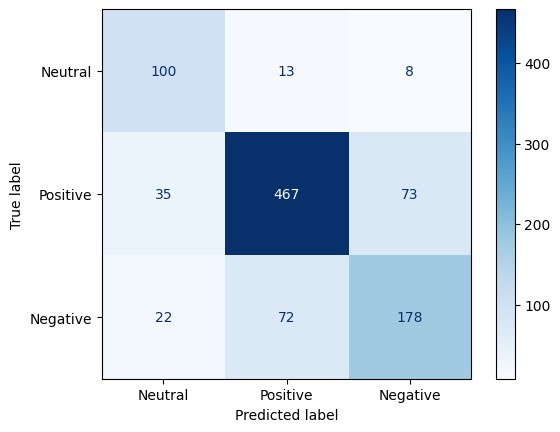

In [37]:
cm = confusion_matrix(y_test, y_pred_2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutral', 'Positive', 'Negative'])
disp.plot(cmap='Blues')

In [49]:
test_text = "Taxpayers set for £10bn loss."
cleaned_text_testing = clean_text_elmo(test_text)
elmo_vector = elmo_embed([cleaned_text_testing])

prediction = LR_model2.predict(elmo_vector)[0]
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
print(f"Predicted Sentiment (Logistic Regression): {label_map[prediction]}")

Predicted Sentiment (Logistic Regression): Negative


## Naive Bayes model

In [56]:
from imblearn.over_sampling import SMOTE

In [40]:
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB

In [43]:
NB_model = GaussianNB()

NB_model.fit(X_train_elmo, y_train)

GaussianNB()

In [44]:
y_pred_nb = NB_model.predict(X_test_elmo)

In [45]:
print("Accuracy (Naive Bayes):", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report (Naive Bayes):\n", classification_report(y_test, y_pred_nb))

Accuracy (Naive Bayes): 0.6033057851239669

Classification Report (Naive Bayes):
               precision    recall  f1-score   support

           0       0.37      0.53      0.43       121
           1       0.71      0.80      0.75       575
           2       0.42      0.22      0.29       272

    accuracy                           0.60       968
   macro avg       0.50      0.52      0.49       968
weighted avg       0.58      0.60      0.58       968



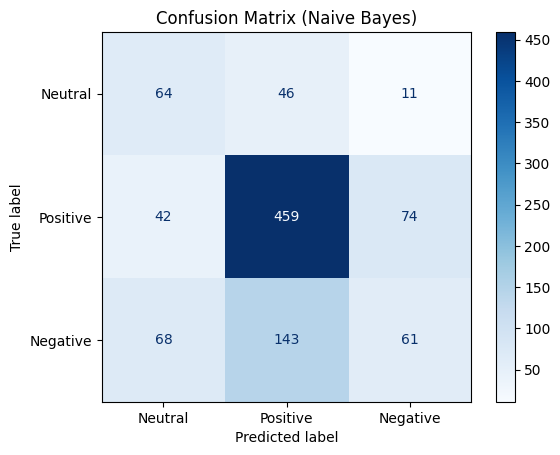

In [46]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Neutral', 'Positive', 'Negative'])
disp_nb.plot(cmap='Blues')
plt.title('Confusion Matrix (Naive Bayes)')
plt.show()

In [48]:
test_text_nb = "Taxpayers set for £10bn loss."
cleaned_text_testing_nb = clean_text_elmo(test_text_nb)
elmo_vector_nb = elmo_embed([cleaned_text_testing_nb])

prediction_nb = NB_model.predict(elmo_vector_nb)[0]
print(f"Predicted Sentiment (Naive Bayes): {label_map[prediction_nb]}")

Predicted Sentiment (Naive Bayes): Positive


In [58]:
smote = SMOTE()

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_elmo, y_train)

In [59]:
NB_model2 = GaussianNB()
NB_model2.fit(X_train_resampled, y_train_resampled)

GaussianNB()

In [60]:
y_pred_nb2 = NB_model2.predict(X_test_elmo)

In [62]:
print("Accuracy (Naive Bayes with SMOTE):", accuracy_score(y_test, y_pred_nb2))
print("\nClassification Report (Naive Bayes with SMOTE):\n", classification_report(y_test, y_pred_nb2))

Accuracy (Naive Bayes with SMOTE): 0.5485537190082644

Classification Report (Naive Bayes with SMOTE):
               precision    recall  f1-score   support

           0       0.25      0.60      0.35       121
           1       0.71      0.71      0.71       575
           2       0.50      0.19      0.27       272

    accuracy                           0.55       968
   macro avg       0.49      0.50      0.44       968
weighted avg       0.59      0.55      0.54       968



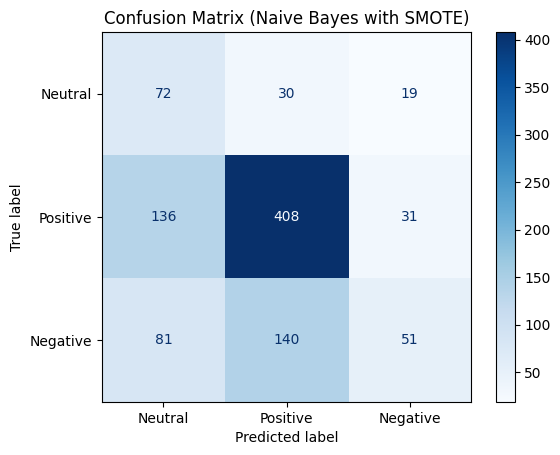

In [67]:
cm_nb2 = confusion_matrix(y_test, y_pred_nb2)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb2, display_labels=['Neutral', 'Positive', 'Negative'])
disp_nb.plot(cmap='Blues')
plt.title('Confusion Matrix (Naive Bayes with SMOTE)')
plt.show()

## K-NN model

In [50]:
from sklearn.neighbors import KNeighborsClassifier

In [52]:
KNN_model = KNeighborsClassifier(n_neighbors=5)

In [53]:
KNN_model.fit(X_train_elmo, y_train)

KNeighborsClassifier()

In [54]:
y_pred_knn = KNN_model.predict(X_test_elmo)

In [55]:
print("Accuracy (K-NN):", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report (K-NN model):\n", classification_report(y_test, y_pred_knn))

Accuracy (K-NN): 0.6849173553719008

Classification Report (K-NN model):
               precision    recall  f1-score   support

           0       0.48      0.47      0.48       121
           1       0.75      0.87      0.80       575
           2       0.58      0.40      0.47       272

    accuracy                           0.68       968
   macro avg       0.60      0.58      0.58       968
weighted avg       0.67      0.68      0.67       968



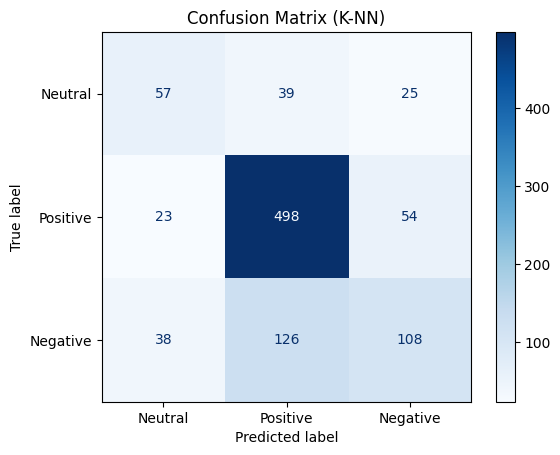

In [64]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Neutral', 'Positive', 'Negative'])
disp_knn.plot(cmap='Blues')
plt.title('Confusion Matrix (K-NN)')
plt.show()

In [65]:
test_text_knn = "Taxpayers set for £10bn loss."
cleaned_text_testing_knn = clean_text_elmo(test_text_knn)
elmo_vector_knn = elmo_embed([cleaned_text_testing_knn])

prediction_knn = KNN_model.predict(elmo_vector_knn)[0]
print(f"Predicted Sentiment (K-NN): {label_map[prediction_knn]}")

Predicted Sentiment (K-NN): Negative


In [66]:
KNN_model2 = KNeighborsClassifier(n_neighbors=5)

KNN_model2.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier()

In [68]:
y_pred_knn2 = KNN_model2.predict(X_test_elmo)

print("Accuracy (K-NN with SMOTE):", accuracy_score(y_test, y_pred_knn2))
print("\nClassification Report (K-NN with SMOTE):\n", classification_report(y_test, y_pred_knn2))

Accuracy (K-NN with SMOTE): 0.5

Classification Report (K-NN with SMOTE):
               precision    recall  f1-score   support

           0       0.32      0.81      0.46       121
           1       0.89      0.38      0.53       575
           2       0.40      0.62      0.49       272

    accuracy                           0.50       968
   macro avg       0.54      0.60      0.49       968
weighted avg       0.68      0.50      0.51       968



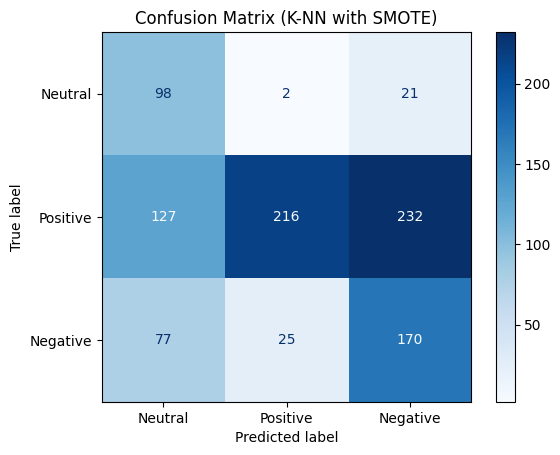

In [69]:
cm_knn2 = confusion_matrix(y_test, y_pred_knn2)
disp_knn2 = ConfusionMatrixDisplay(confusion_matrix=cm_knn2, display_labels=['Neutral', 'Positive', 'Negative'])
disp_knn2.plot(cmap='Blues')
plt.title('Confusion Matrix (K-NN with SMOTE)')
plt.show()

### Try with multiple values of k neighbors

In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

In [71]:
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 10, 15, 21]
}

In [72]:
knn = KNeighborsClassifier(weights='distance')

In [79]:
# cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(knn, param_grid, scoring='accuracy', cv=cv)
grid.fit(X_train_elmo, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KNeighborsClassifier(weights='distance'),
             param_grid={'n_neighbors': [1, 3, 5, 7, 10, 15, 21]},
             scoring='accuracy')

In [82]:
print(f"Best k: {grid.best_params_['n_neighbors']}")
print(f"Best Accuracy Score: {grid.best_score_*100:.2f}%")

Best k: 7
Best Accuracy Score: 70.16%
